<a href="https://colab.research.google.com/github/ka4382/self-pruning-neural-network_Tredence_CaseStudy/blob/main/Tredence_caseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Better initialization
        self.gate_scores = nn.Parameter(torch.ones(out_features, in_features))

    def forward(self, x):
        # sharper sigmoid (important)
        gates = torch.sigmoid(self.gate_scores * 2)

        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

In [4]:
class PruningNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [5]:
transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

In [6]:
def compute_sparsity_loss(model):
    loss = 0
    count = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores * 2)
            loss += torch.mean(gates)
            count += 1

    return loss / count

In [7]:
def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


def calculate_sparsity(model, threshold=0.05):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores * 2)

            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    return 100 * pruned / total

In [8]:
def train_model(lambda_val, epochs=10):
    model = PruningNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            cls_loss = criterion(outputs, labels)
            sparse_loss = compute_sparsity_loss(model)

            loss = cls_loss + lambda_val * sparse_loss

            loss.backward()
            optimizer.step()

        print(f"Lambda {lambda_val} | Epoch {epoch+1} done")

    acc = evaluate(model)
    sparsity = calculate_sparsity(model)

    return model, acc, sparsity

In [9]:
lambda_values = [0.5, 1.0, 2.0]

results = []

for lam in lambda_values:
    print(f"\nRunning for lambda = {lam}")

    model, acc, sparsity = train_model(lam)

    results.append((lam, acc, sparsity))

    print(f"Accuracy: {acc:.2f}%")
    print(f"Sparsity: {sparsity:.2f}%")


Running for lambda = 0.5
Lambda 0.5 | Epoch 1 done
Lambda 0.5 | Epoch 2 done
Lambda 0.5 | Epoch 3 done
Lambda 0.5 | Epoch 4 done
Lambda 0.5 | Epoch 5 done
Lambda 0.5 | Epoch 6 done
Lambda 0.5 | Epoch 7 done
Lambda 0.5 | Epoch 8 done
Lambda 0.5 | Epoch 9 done
Lambda 0.5 | Epoch 10 done
Accuracy: 51.18%
Sparsity: 57.15%

Running for lambda = 1.0
Lambda 1.0 | Epoch 1 done
Lambda 1.0 | Epoch 2 done
Lambda 1.0 | Epoch 3 done
Lambda 1.0 | Epoch 4 done
Lambda 1.0 | Epoch 5 done
Lambda 1.0 | Epoch 6 done
Lambda 1.0 | Epoch 7 done
Lambda 1.0 | Epoch 8 done
Lambda 1.0 | Epoch 9 done
Lambda 1.0 | Epoch 10 done
Accuracy: 50.23%
Sparsity: 59.64%

Running for lambda = 2.0
Lambda 2.0 | Epoch 1 done
Lambda 2.0 | Epoch 2 done
Lambda 2.0 | Epoch 3 done
Lambda 2.0 | Epoch 4 done
Lambda 2.0 | Epoch 5 done
Lambda 2.0 | Epoch 6 done
Lambda 2.0 | Epoch 7 done
Lambda 2.0 | Epoch 8 done
Lambda 2.0 | Epoch 9 done
Lambda 2.0 | Epoch 10 done
Accuracy: 51.01%
Sparsity: 61.09%


In [10]:
print("\nFinal Results:")
for lam, acc, sparsity in results:
    print(f"Lambda: {lam}, Accuracy: {acc:.2f}%, Sparsity: {sparsity:.2f}%")


Final Results:
Lambda: 0.5, Accuracy: 51.18%, Sparsity: 57.15%
Lambda: 1.0, Accuracy: 50.23%, Sparsity: 59.64%
Lambda: 2.0, Accuracy: 51.01%, Sparsity: 61.09%


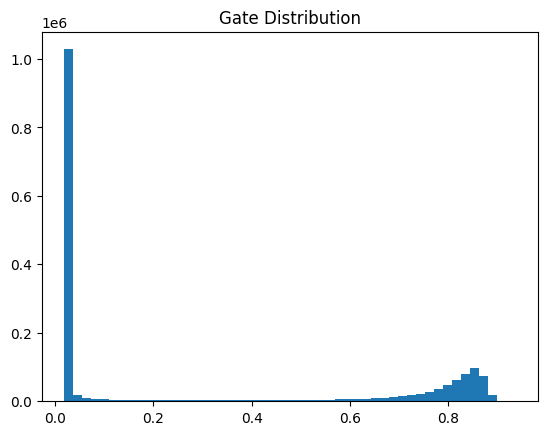

In [11]:
def plot_gates(model):
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores * 2).detach().cpu().numpy()
            all_gates.extend(gates.flatten())

    plt.hist(all_gates, bins=50)
    plt.title("Gate Distribution")
    plt.show()

# Plot for last model
plot_gates(model)